In [1]:

# Install PySpark
!pip install pyspark


In [2]:

# Initialize Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("ClusteringModel").getOrCreate()
print("SparkSession initialized successfully!")

SparkSession initialized successfully!


In [3]:

from tensorflow.keras.datasets import mnist
import pandas as pd

(x_train, y_train), _ = mnist.load_data()

# Take subset
x = x_train[:5000]
y = y_train[:5000]

print("Shape:", x.shape)
print("Unique labels:", set(y))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (5000, 28, 28)
Unique labels: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)}


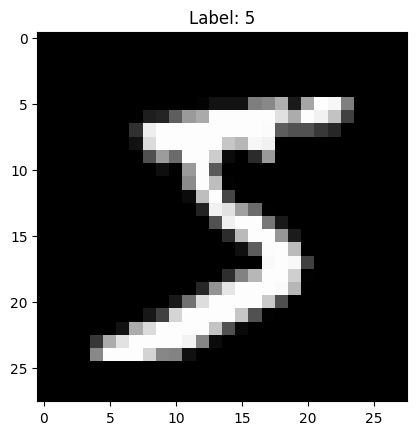

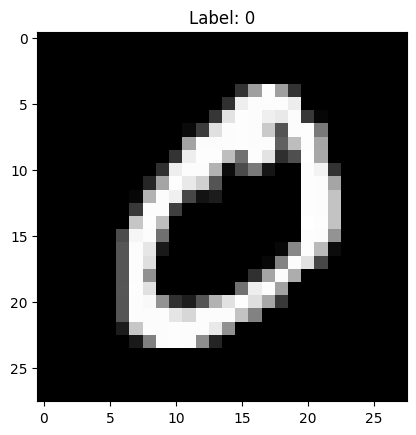

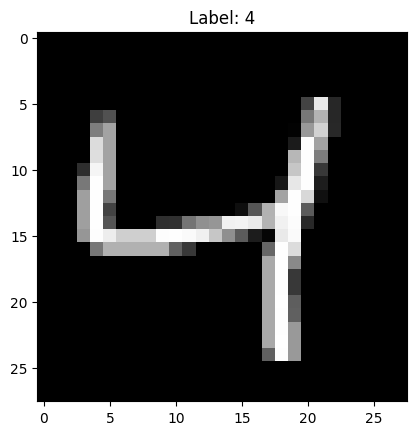

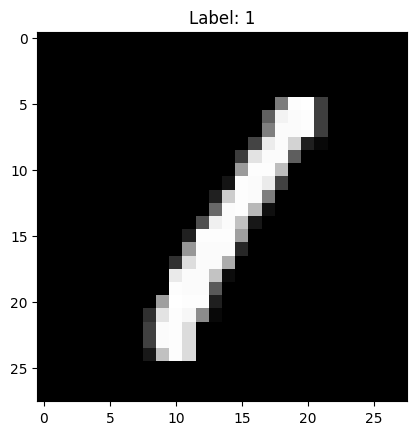

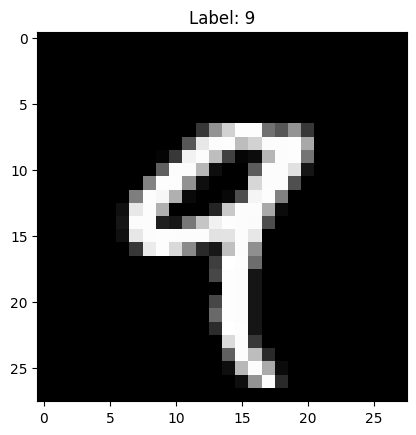

In [4]:

import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(x[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.show()

In [5]:
x_flat = x.reshape(x.shape[0], -1)

pdf = pd.DataFrame(x_flat)
pdf['label'] = y

print("Pandas shape:", pdf.shape)
pdf.head()

Pandas shape: (5000, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [6]:

df = spark.createDataFrame(pdf)

df.show(5)
df.printSchema()
print("Total rows:", df.count())

+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---

In [7]:
# Count per digit
df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    0|  479|
|    7|  550|
|    6|  501|
|    9|  495|
|    5|  434|
|    1|  563|
|    3|  493|
|    8|  462|
|    2|  488|
|    4|  535|
+-----+-----+



In [8]:
from pyspark.ml.feature import VectorAssembler

feature_cols = df.columns[:-1]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

data = assembler.transform(df)
data.select("features").show(3)

+--------------------+
|            features|
+--------------------+
|(784,[152,153,154...|
|(784,[127,128,129...|
|(784,[160,161,162...|
+--------------------+
only showing top 3 rows


In [9]:

from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=10, seed=1)
model = kmeans.fit(data)

In [10]:
predictions = model.transform(data)

predictions.select("label", "prediction").show(20)

+-----+----------+
|label|prediction|
+-----+----------+
|    5|         2|
|    0|         0|
|    4|         3|
|    1|         4|
|    9|         5|
|    2|         9|
|    1|         4|
|    3|         2|
|    1|         4|
|    4|         5|
|    3|         6|
|    5|         4|
|    3|         6|
|    6|         1|
|    1|         4|
|    7|         5|
|    2|         9|
|    8|         2|
|    6|         7|
|    9|         5|
+-----+----------+
only showing top 20 rows


In [11]:
predictions.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|  354|
|         6|  367|
|         3|  819|
|         5|  693|
|         9|  341|
|         4|  793|
|         8|  428|
|         7|  469|
|         2|  350|
|         0|  386|
+----------+-----+



In [12]:
predictions.groupBy("label", "prediction").count().orderBy("label").show(50)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|         6|   10|
|    0|         0|  369|
|    0|         1|    5|
|    0|         7|   70|
|    0|         8|   20|
|    0|         2|    1|
|    0|         3|    4|
|    1|         7|    1|
|    1|         4|  553|
|    1|         2|    5|
|    1|         8|    3|
|    1|         6|    1|
|    2|         8|   14|
|    2|         6|   16|
|    2|         9|  315|
|    2|         7|   17|
|    2|         3|   13|
|    2|         5|    2|
|    2|         2|   20|
|    2|         1|   15|
|    2|         4|   74|
|    2|         0|    2|
|    3|         9|    9|
|    3|         7|   13|
|    3|         6|  218|
|    3|         1|    1|
|    3|         0|    1|
|    3|         3|   10|
|    3|         5|    3|
|    3|         8|  105|
|    3|         2|  103|
|    3|         4|   30|
|    4|         9|    6|
|    4|         7|   29|
|    4|         3|  333|
|    4|         4|   19|
|    4|         1|    7|


In [13]:

from pyspark.sql.functions import desc

dominant = predictions.groupBy("prediction", "label") \
    .count() \
    .orderBy("prediction", desc("count"))

dominant.show(20)

+----------+-----+-----+
|prediction|label|count|
+----------+-----+-----+
|         0|    0|  369|
|         0|    6|    6|
|         0|    5|    4|
|         0|    9|    2|
|         0|    2|    2|
|         0|    3|    1|
|         0|    8|    1|
|         0|    7|    1|
|         1|    6|  316|
|         1|    2|   15|
|         1|    5|    8|
|         1|    4|    7|
|         1|    0|    5|
|         1|    3|    1|
|         1|    9|    1|
|         1|    8|    1|
|         2|    8|  204|
|         2|    3|  103|
|         2|    2|   20|
|         2|    5|   15|
+----------+-----+-----+
only showing top 20 rows


In [14]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator()

score = evaluator.evaluate(predictions)
print("Silhouette Score:", score)

Silhouette Score: 0.1303731676850743


In [15]:
predictions.filter(predictions.prediction == 0).show(5)
predictions.filter(predictions.prediction == 1).show(5)

+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---

NameError: name 'centers' is not defined

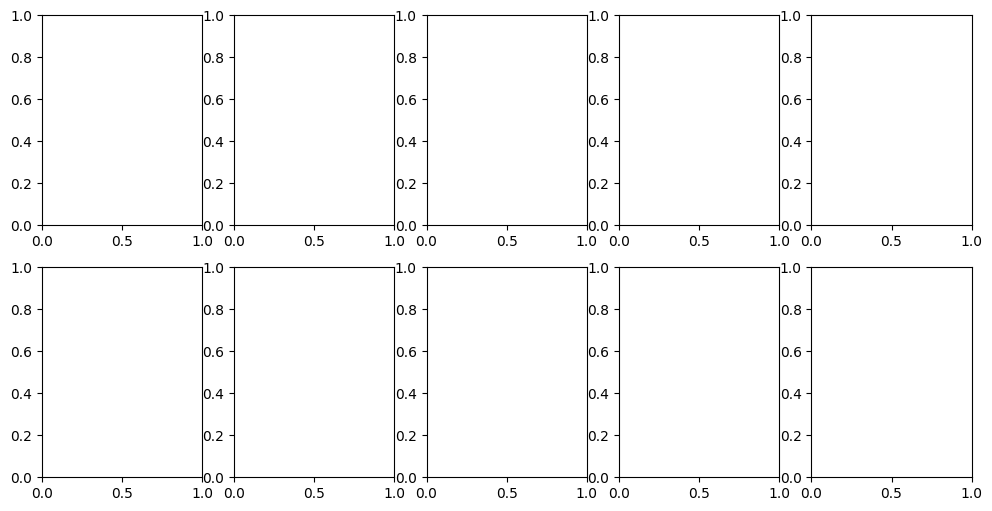

In [16]:

import matplotlib.pyplot as plt
import numpy as np

# Reshape cluster centers to 28x28 images for visualization
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, center in enumerate(centers):
    ax = axes[i]
    # Reshape the 784-dimensional vector back to 28x28 image
    image = center.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Cluster {i}')
    ax.axis('off') # Hide axes ticks

plt.tight_layout()
plt.show()

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, desc


dominant_label_per_cluster = dominant.groupBy("prediction").agg({'label': 'first'}).withColumnRenamed('first(label)', 'dominant_label')
predictions_with_labels = predictions.join(dominant_label_per_cluster, on="prediction", how="left")
cluster_label_counts_pdf = predictions_with_labels.groupBy("prediction", "label").count().toPandas()

heatmap_data = cluster_label_counts_pdf.pivot_table(index='prediction', columns='label', values='count', fill_value=0)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='viridis', linewidths=.5)
plt.title('Distribution of True Labels within K-Means Clusters')
plt.xlabel('True Label (Digit)')
plt.ylabel('Predicted Cluster')
plt.show()
